In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")

print("Path to dataset files:", path)

100%|██████████| 1.99M/1.99M [00:00<00:00, 78.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jp797498e/twitter-entity-sentiment-analysis/versions/2


In [2]:
import os
print(os.listdir(path))

['twitter_training.csv', 'twitter_validation.csv']


In [3]:
import pandas as pd
import os
file_path = os.path.join(path, "twitter_training.csv")
df = pd.read_csv(file_path, header=None)
df.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
df.columns = ["Tweet_ID", "Entity", "Sentiment", "Tweet_Content"]
df.head()

,Tweet_ID,Entity,Sentiment,Tweet_Content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (74682, 4)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tweet_ID       74682 non-null  int64 
 1   Entity         74682 non-null  object
 2   Sentiment      74682 non-null  object
 3   Tweet_Content  73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [7]:
df.isnull().sum()

,0
Tweet_ID,0
Entity,0
Sentiment,0
Tweet_Content,686


In [8]:
df.duplicated().sum()

np.int64(2700)

In [9]:
df["Sentiment"].value_counts()

,count
Sentiment,
Negative,22542
Positive,20832
Neutral,18318
Irrelevant,12990


In [10]:
df = df.dropna(subset=["Tweet_Content"])
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Tweet_ID         0
Entity           0
Sentiment        0
Tweet_Content    0
dtype: int64


In [11]:
df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())
print("Dataset shape after cleaning:", df.shape)

Duplicates after removal: 0
Dataset shape after cleaning: (71656, 4)


In [12]:
df = df[df["Sentiment"] != "Irrelevant"]
print(df["Sentiment"].value_counts())

Sentiment
Negative    21698
Positive    19713
Neutral     17708
Name: count, dtype: int64


In [13]:
df = df.reset_index(drop=True)
df.head()

,Tweet_ID,Entity,Sentiment,Tweet_Content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


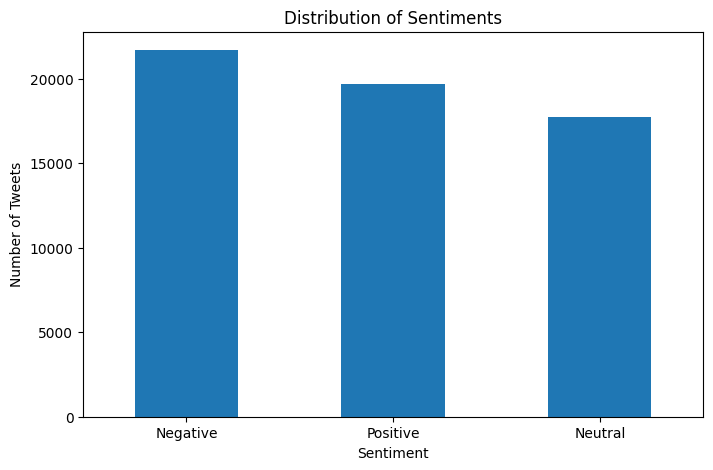

In [14]:
import matplotlib.pyplot as plt
sentiment_counts = df["Sentiment"].value_counts()
plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind="bar")
plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.show()

In [15]:
df["Entity"].value_counts().head(10)

,count
Entity,
TomClancysGhostRecon,2268
TomClancysRainbowSix,2236
MaddenNFL,2229
Verizon,2142
Microsoft,2137
NBA2K,2124
Nvidia,2112
ApexLegends,2093
WorldOfCraft,2090


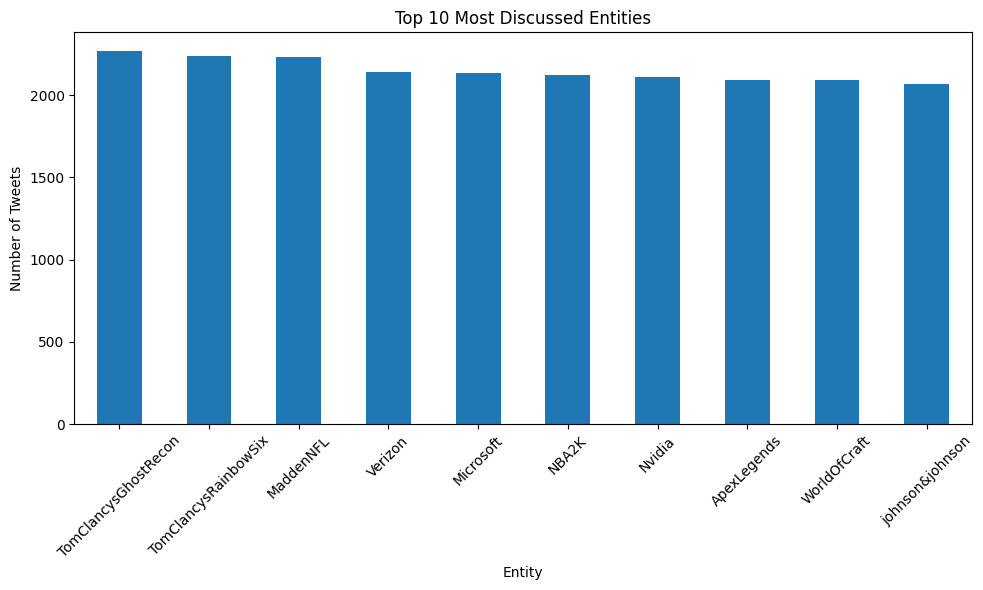

In [16]:
top_entities = df["Entity"].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_entities.plot(kind="bar")
plt.title("Top 10 Most Discussed Entities")
plt.xlabel("Entity")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [18]:
stop_words = set(stopwords.words("english"))

negation_words = {"no", "not", "nor", "never"}
stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\\S+|www\\S+|pic\\.twitter\\.com\\S*", "", text)
    text = re.sub(r"@\\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [19]:
df["Cleaned_Text"] = df["Tweet_Content"].apply(preprocess_text)

In [20]:
df[["Tweet_Content", "Cleaned_Text"]].head(10)

,Tweet_Content,Cleaned_Text
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder
5,im getting into borderlands and i can murder y...,im getting borderland murder
6,So I spent a few hours making something for fu...,spent hour making something fun know huge bord...
7,So I spent a couple of hours doing something f...,spent couple hour something fun know huge bord...
8,So I spent a few hours doing something for fun...,spent hour something fun know huge borderland ...
9,So I spent a few hours making something for fu...,spent hour making something fun know huge rhan...


In [21]:
stop_words = set(stopwords.words("english"))

In [22]:
from collections import Counter
all_text = " ".join(df["Cleaned_Text"])
all_words = all_text.split()
noise_words = {"com", "pic", "twitter", "https", "http", "www", "unk"}
filtered_words = [word for word in all_words if word not in noise_words]

word_counts = Counter(filtered_words)
top_20_words = word_counts.most_common(20)
top_20_words

[('game', 10475),
 ('not', 5204),
 ('like', 3912),
 ('get', 3787),
 ('play', 3202),
 ('one', 3013),
 ('johnson', 3011),
 ('k', 2990),
 ('time', 2977),
 ('new', 2861),
 ('good', 2839),
 ('no', 2828),
 ('u', 2750),
 ('really', 2685),
 ('love', 2549),
 ('p', 2296),
 ('co', 2279),
 ('shit', 2248),
 ('amazon', 2193),
 ('people', 2144)]

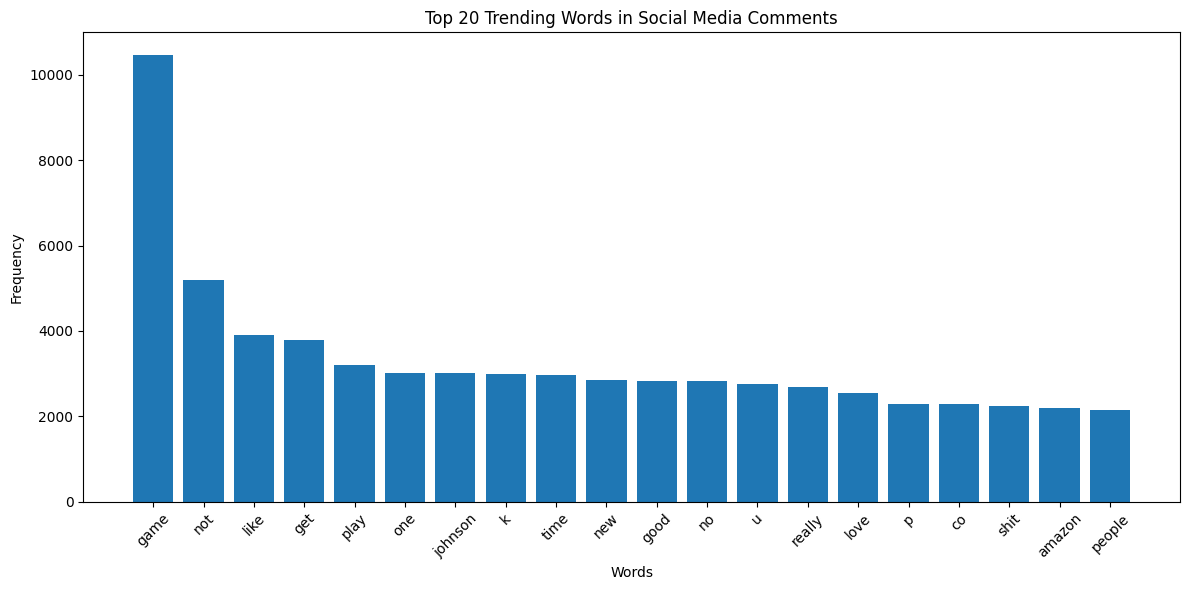

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
top_words_df = pd.DataFrame(
    top_20_words,
    columns=["Word", "Frequency"]
)
plt.figure(figsize=(12, 6))
plt.bar(
    top_words_df["Word"],
    top_words_df["Frequency"]
)
plt.title("Top 20 Trending Words in Social Media Comments")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
from nltk.util import bigrams

bigram_list = list(bigrams(all_words))
bigram_counts = Counter(bigram_list)
top_20_bigrams = bigram_counts.most_common(20)
top_20_bigrams

[(('twitter', 'com'), 2795),
 (('pic', 'twitter'), 2682),
 (('http', 'co'), 1851),
 (('red', 'dead'), 1346),
 (('nba', 'k'), 1305),
 (('johnson', 'johnson'), 1258),
 (('rainbow', 'game'), 1172),
 (('dead', 'redemption'), 1051),
 (('home', 'depot'), 978),
 (('twitch', 'tv'), 890),
 (('assassin', 'creed'), 748),
 (('call', 'duty'), 686),
 (('rhandlerr', 'rhandlerr'), 678),
 (('series', 'x'), 640),
 (('xbox', 'series'), 598),
 (('league', 'legend'), 586),
 (('italy', 'italy'), 475),
 (('black', 'ops'), 464),
 (('not', 'access'), 419),
 (('access', 'health'), 417)]

In [25]:
top_bigrams_df = pd.DataFrame(
    [
        (" ".join(words), frequency)
        for words, frequency in top_20_bigrams
    ],
    columns=["Bigram", "Frequency"]
)

top_bigrams_df

,Bigram,Frequency
0,twitter com,2795
1,pic twitter,2682
2,http co,1851
3,red dead,1346
4,nba k,1305
5,johnson johnson,1258
6,rainbow game,1172
7,dead redemption,1051
8,home depot,978
9,twitch tv,890


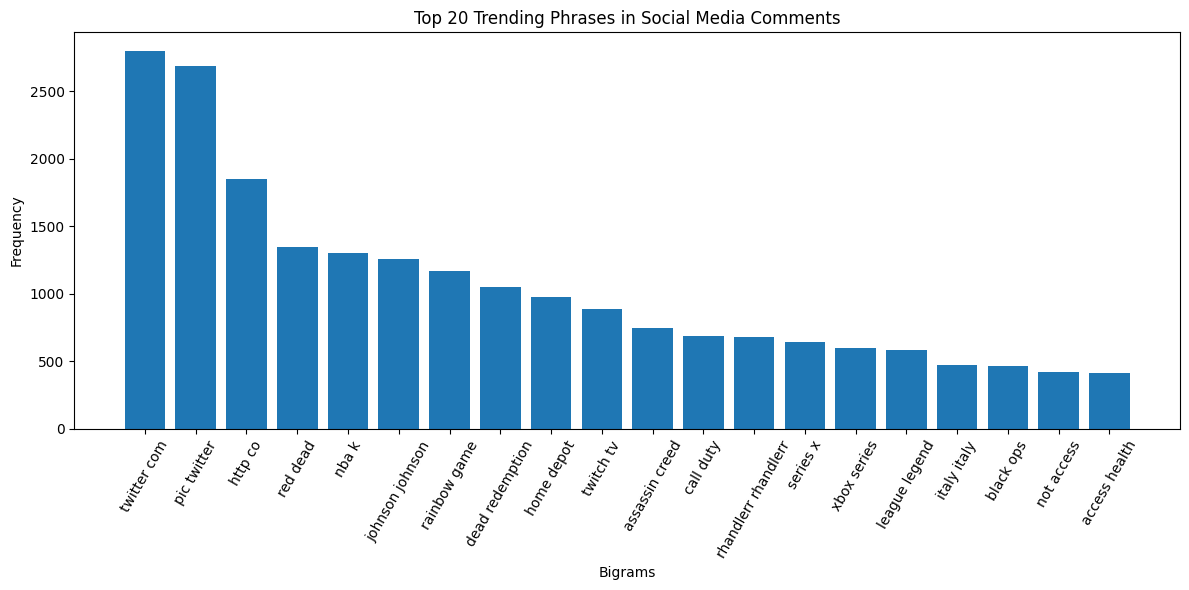

In [26]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_bigrams_df["Bigram"],
    top_bigrams_df["Frequency"]
)

plt.title("Top 20 Trending Phrases in Social Media Comments")
plt.xlabel("Bigrams")
plt.ylabel("Frequency")
plt.xticks(rotation=60)
plt.tight_layout()

plt.show()

In [27]:
X = df["Cleaned_Text"]
y = df["Sentiment"]
print(X.shape)
print(y.shape)

(59119,)
(59119,)


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (47295,)
Testing size: (11824,)


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=10000,ngram_range=(1, 2),min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (47295, 10000)
Testing TF-IDF shape: (11824, 10000)


In [30]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000,class_weight="balanced")
model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [31]:
y_pred = model.predict(X_test_tfidf)
y_pred[:10]

array(['Positive', 'Negative', 'Positive', 'Neutral', 'Negative',
       'Positive', 'Positive', 'Positive', 'Neutral', 'Neutral'],
      dtype=object)

In [32]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.795585250338295

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83      4340
     Neutral       0.77      0.75      0.76      3541
    Positive       0.77      0.81      0.79      3943

    accuracy                           0.80     11824
   macro avg       0.79      0.79      0.79     11824
weighted avg       0.80      0.80      0.80     11824



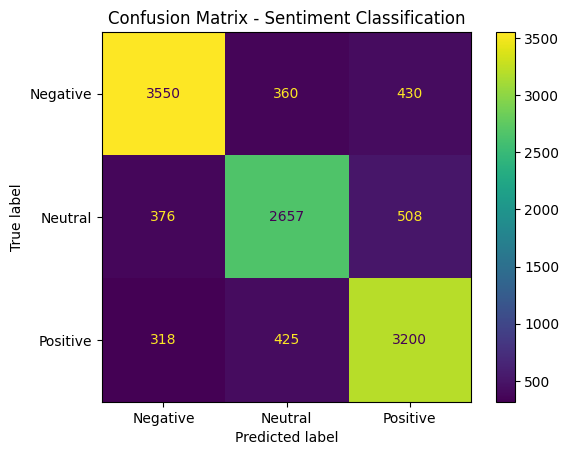

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot()
plt.title("Confusion Matrix - Sentiment Classification")
plt.show()

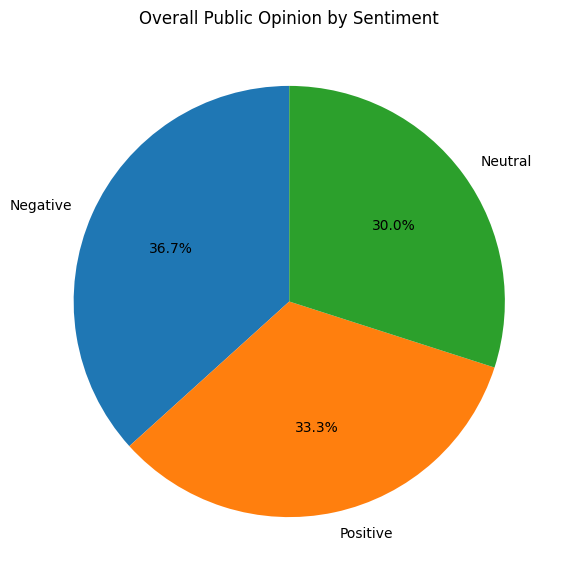

In [34]:
sentiment_counts = df["Sentiment"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(sentiment_counts.values,labels=sentiment_counts.index,autopct="%1.1f%%",startangle=90)
plt.title("Overall Public Opinion by Sentiment")
plt.show()

In [35]:
top_10_entities = df["Entity"].value_counts().head(10).index
top_entity_data = df[df["Entity"].isin(top_10_entities)]
entity_sentiment = pd.crosstab(top_entity_data["Entity"],top_entity_data["Sentiment"])
entity_sentiment

Sentiment,Negative,Neutral,Positive
Entity,,,
ApexLegends,574,913,606
MaddenNFL,1665,191,373
Microsoft,748,816,573
NBA2K,1450,265,409
Nvidia,503,848,761
TomClancysGhostRecon,887,776,605
TomClancysRainbowSix,1110,628,498
Verizon,1070,552,520
WorldOfCraft,328,1047,715


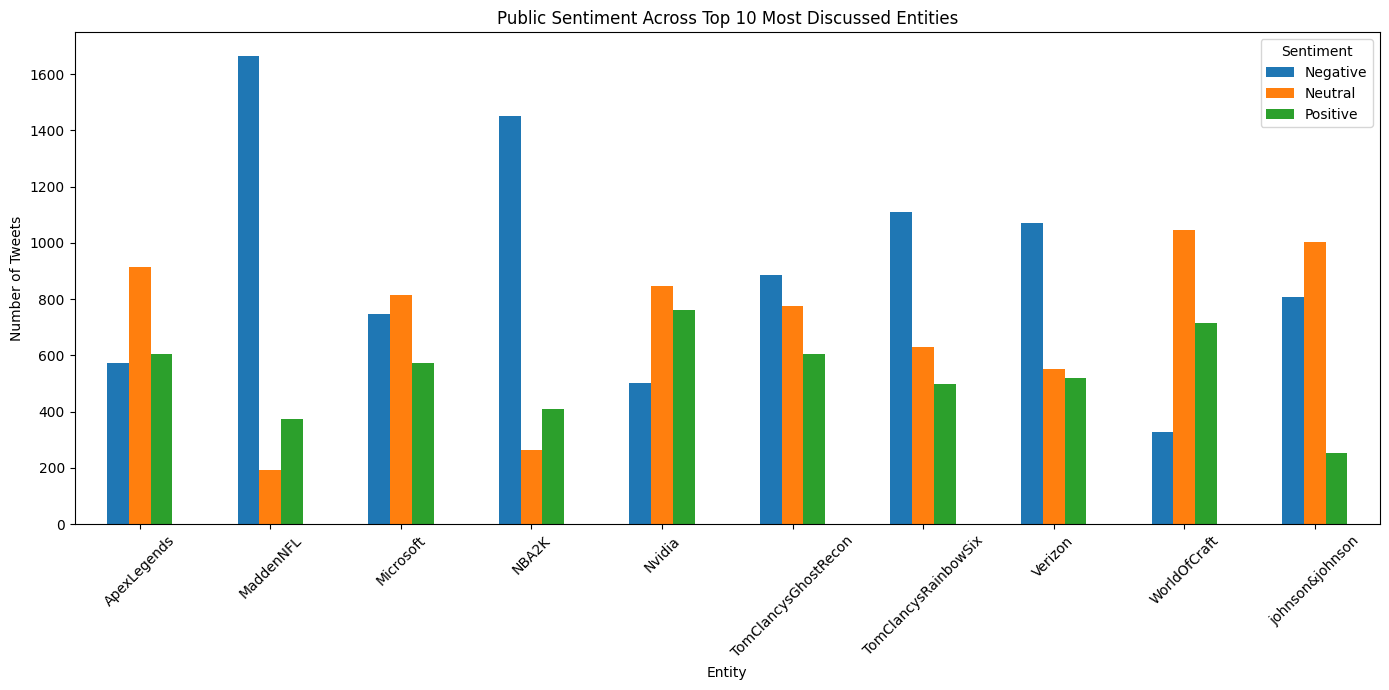

In [36]:
entity_sentiment.plot(kind="bar",figsize=(14, 7))
plt.title("Public Sentiment Across Top 10 Most Discussed Entities")
plt.xlabel("Entity")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [37]:
entity_sentiment_all = pd.crosstab(df["Entity"],df["Sentiment"])
entity_sentiment_all.head()

Sentiment,Negative,Neutral,Positive
Entity,,,
Amazon,565,1197,302
ApexLegends,574,913,606
AssassinsCreed,365,153,1382
Battlefield,445,342,561
Borderlands,415,581,972


In [38]:
top_positive_entities = entity_sentiment_all.sort_values(by="Positive",ascending=False).head(10)
top_positive_entities

Sentiment,Negative,Neutral,Positive
Entity,,,
AssassinsCreed,365,153,1382
Borderlands,415,581,972
Cyberpunk2077,360,456,902
PlayStation5(PS5),422,490,890
RedDeadRedemption(RDR),290,776,885
CallOfDutyBlackopsColdWar,540,340,817
Hearthstone,514,681,806
Nvidia,503,848,761
Xbox(Xseries),355,403,743


In [39]:
top_negative_entities = entity_sentiment_all.sort_values(by="Negative",ascending=False).head(10)
top_negative_entities

Sentiment,Negative,Neutral,Positive
Entity,,,
MaddenNFL,1665,191,373
NBA2K,1450,265,409
FIFA,1127,100,473
TomClancysRainbowSix,1110,628,498
Verizon,1070,552,520
TomClancysGhostRecon,887,776,605
HomeDepot,871,330,731
CallOfDuty,861,367,426
johnson&johnson,809,1004,252


In [40]:
def predict_sentiment(text):
    cleaned_text = preprocess_text(text)
    vectorized_text = tfidf.transform([cleaned_text])
    prediction = model.predict(vectorized_text)[0]
    return prediction

In [41]:
predict_sentiment("I absolutely love this product, it is amazing!")

'Positive'

In [42]:
predict_sentiment("This is the worst service I have ever experienced.")

'Negative'

In [43]:
predict_sentiment("The new update was released yesterday.")

'Positive'